In [3]:
#impor library
import pandas as pd
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

#load
dataset_dick ={
    'Outlook': ['sunny', 'sunny', 'overcast', 'rainy', 'rainy', 'rainy', 'overcast', 'sunny', 'sunny', 'rainy', 'sunny', 'overcast', 'overcast', 'rainy', 'sunny', 'overcast', 'rainy', 'sunny', 'sunny', 'rainy', 'overcast', 'rainy', 'sunny', 'overcast', 'sunny', 'overcast', 'rainy', 'overcast'],
    'Temperature': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0, 72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0, 88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
    'Humidity': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0, 90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0, 65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
    'Wind': [False, True, False, False, False, True, True, False, False, False, True, True, False, True, True, False, False, True, False, True, True, False, True, False, False, True, False, False],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(dataset_dick)
df.head()


,Outlook,Temperature,Humidity,Wind,Play
0,sunny,85.0,85.0,False,No
1,sunny,80.0,90.0,True,No
2,overcast,83.0,78.0,False,Yes
3,rainy,70.0,96.0,False,Yes
4,rainy,68.0,80.0,False,Yes


<Axes: >

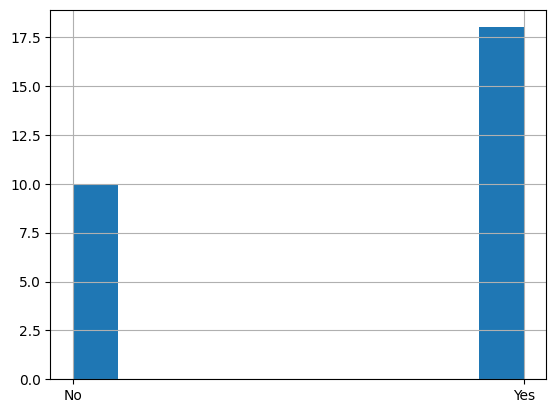

In [4]:
df["Play"].hist()

In [5]:
#one hot
df = pd.get_dummies(df, columns=['Outlook'], prefix='', prefix_sep='', dtype=int)

#convert
df['Wind'] = df['Wind'].astype(int)
df['Play'] = (df['Play'] == 'Yes').astype(int)

df.head()

,Temperature,Humidity,Wind,Play,overcast,rainy,sunny
0,85.0,85.0,0,0,0,0,1
1,80.0,90.0,1,0,0,0,1
2,83.0,78.0,0,1,1,0,0
3,70.0,96.0,0,1,0,1,0
4,68.0,80.0,0,1,0,1,0


In [6]:
#define
df['Temperature'] = pd.cut(df['Temperature'], bins=[0, 80, 100], labels = ['Warm', 'Hot'])
df['Humidity'] = pd.cut(df['Humidity'], bins=[0, 80, 100], labels = ['Dry','Humid'])

#one hot
one_hot_colums = pd.get_dummies(df[['Temperature', 'Humidity']],drop_first=True, dtype=int)
df = df.drop(['Temperature', 'Humidity'], axis=1)

#concate
df = pd.concat([df, one_hot_colums], axis=1)

df.head()

,Wind,Play,overcast,rainy,sunny,Temperature_Hot,Humidity_Humid
0,0,0,0,0,1,1,1
1,1,0,0,0,1,0,1
2,0,1,1,0,0,1,0
3,0,1,0,1,0,0,1
4,0,1,0,1,0,0,0


In [7]:
# Split data
X, y = df.drop(columns=['Play']), df['Play']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, shuffle = False)

In [17]:
#train model
nb_clf = BernoulliNB()
nb_clf.fit(X_train, y_train)

BernoulliNB()

In [14]:
#make predict
y_pred = nb_clf.predict(X_test)

#chech acuracy
print("Acuracy : ",accuracy_score(y_test, y_pred))

Acuracy :  0.7


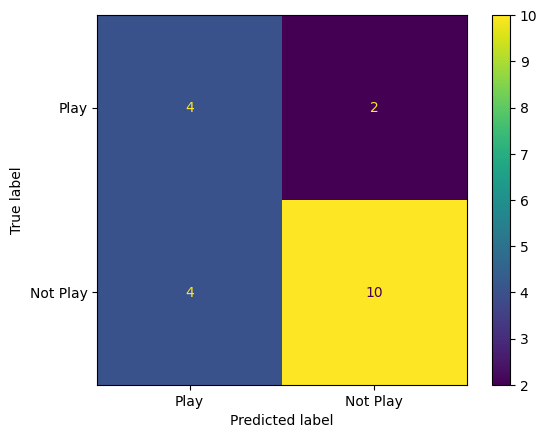

In [16]:
from sklearn.metrics import(
    confusion_matrix,
    ConfusionMatrixDisplay
)
labels = ["Play", "Not Play"]
cm = confusion_matrix(y_test, y_pred)
dis = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
dis.plot()